<a href="https://colab.research.google.com/github/KarimAhmedAI/Fashion-MNIST-Image-Classification/blob/main/Fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [69]:
fashion_mnist=tf.keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

In [70]:
x_train.shape

(60000, 28, 28)

In [71]:
x_test.shape

(10000, 28, 28)

In [72]:
names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [73]:
x_train=x_train/255.0
x_test=x_test/255.0

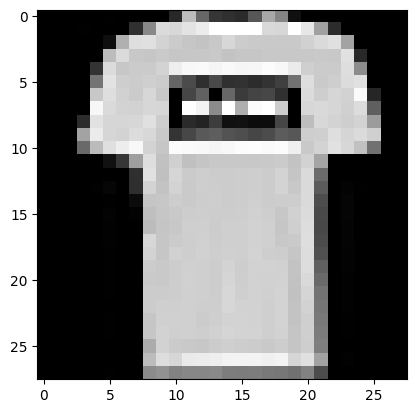

In [74]:
plt.imshow(x_train[1],cmap='gray')

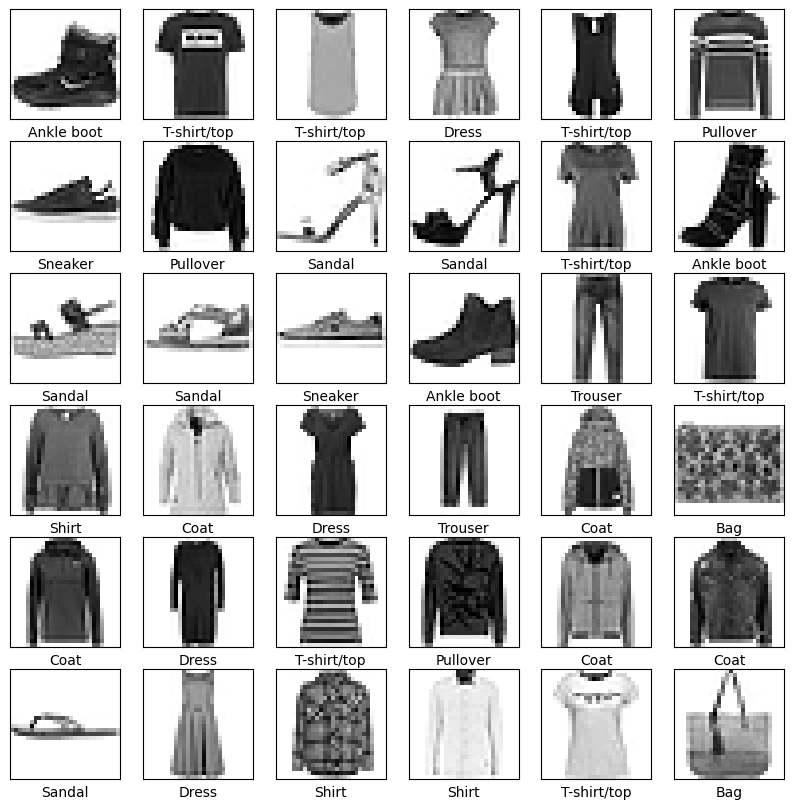

In [75]:
plt.figure(figsize=(10,10))
for i in range(36):
  plt.subplot(6,6,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[i],cmap=plt.cm.binary)
  plt.xlabel(names[y_train[i]])
plt.show()


In [76]:
model=keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [77]:
model.fit(x_train,y_train,epochs=8,batch_size=32,validation_split=0.2)

Epoch 1/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8135 - loss: 0.5196 - val_accuracy: 0.8376 - val_loss: 0.4524
Epoch 2/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8605 - loss: 0.3820 - val_accuracy: 0.8708 - val_loss: 0.3644
Epoch 3/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8740 - loss: 0.3464 - val_accuracy: 0.8683 - val_loss: 0.3543
Epoch 4/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8837 - loss: 0.3191 - val_accuracy: 0.8771 - val_loss: 0.3467
Epoch 5/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8882 - loss: 0.2997 - val_accuracy: 0.8727 - val_loss: 0.3482
Epoch 6/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8934 - loss: 0.2873 - val_accuracy: 0.8788 - val_loss: 0.3525
Epoch 7/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8970 - loss: 0.2749 - val_accuracy: 0.8822 - val_loss: 0.3304
Epoch 8/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9008 - loss: 0.2632 - val_accu

In [78]:
loss,acc=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8740 - loss: 0.3636


In [79]:
pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


9
Ankle boot


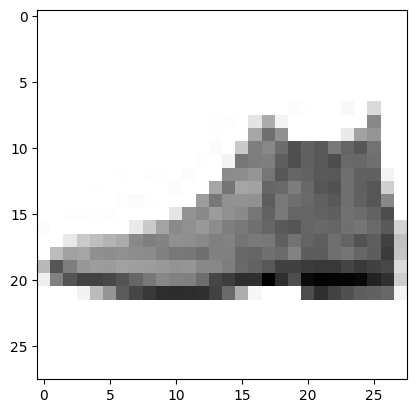

In [80]:
print(np.argmax(pred[0]))
print(names[np.argmax(pred[0])])
plt.imshow(x_test[0],cmap=plt.cm.binary)


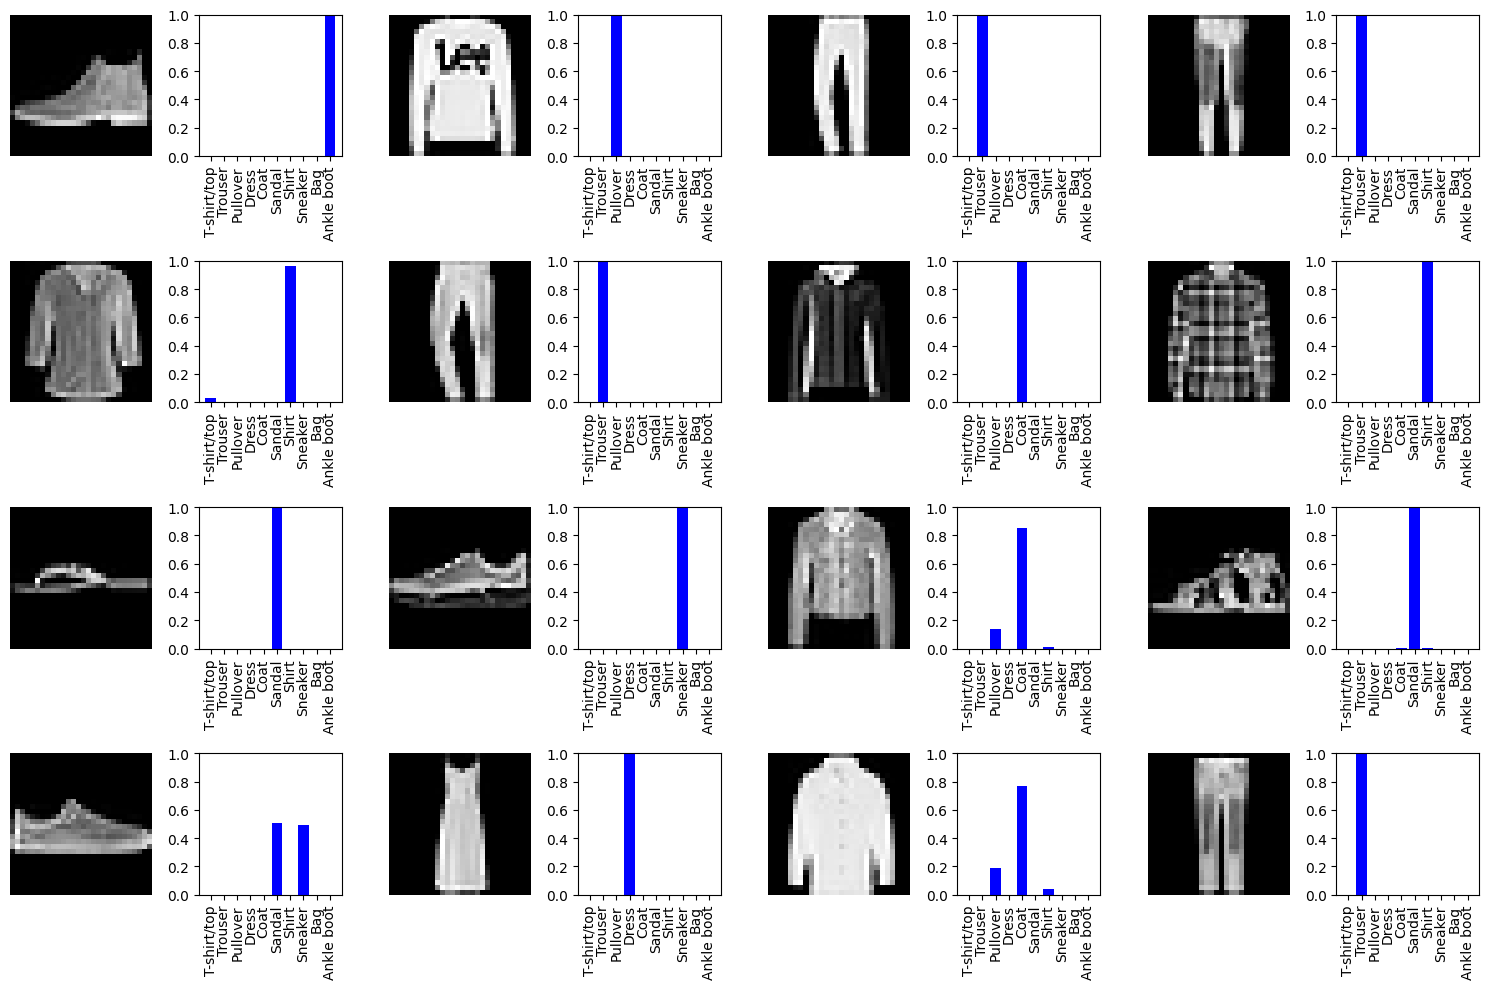

In [81]:
def plot_image(i):
    plt.imshow(x_test[i], cmap='gray')

    pred_label = np.argmax(pred[i])
    true_label = y_test[i]

    color = "blue" if pred_label == true_label else "red"

    plt.xlabel(f"{names[pred_label]} ({np.max(pred[i])*100:.0f}%)",
               color=color)

def plot_value_array(i):
    plt.bar(range(10), pred[i], color="blue")
    plt.xticks(range(10), names, rotation=90)
    plt.ylim([0, 1])

# ===== GRID =====
num_rows = 4
num_cols = 4
num_images = num_rows * num_cols

plt.figure(figsize=(15, 10))

for i in range(num_images):

    # الصورة
    plt.subplot(num_rows, num_cols*2, 2*i+1)
    plot_image(i)
    plt.axis('off')

    # الاحتمالات
    plt.subplot(num_rows, num_cols*2, 2*i+2)
    plot_value_array(i)

plt.tight_layout()
plt.show()